In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [3]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [3]:
!pip install nibabel nilearn tf-keras-vis shap imbalanced-learn pytest -q
!pip install scikit-learn matplotlib seaborn pandas numpy pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 4.9 MB/s eta 0:00:00


In [4]:
%%writefile /content/drive/MyDrive/alzheimer-ai/src/preprocessing.py
"""
MRI preprocessing pipeline for OASIS-2.
Deliverable L2 — Digital Health Engineering PFA 2024–2025.

Steps:
1. Load NIfTI / Analyze MRI file
2. Skull stripping using nilearn brain mask
3. Extract median axial slice
4. Normalize intensity to [0, 1]
5. Resize to 224x224
6. Convert to 3 channels for ResNet50
"""

import os
from typing import Tuple

import nibabel as nib
import numpy as np
from PIL import Image
import nilearn.image as nli
from nilearn.masking import compute_brain_mask


def skull_strip(nii_path: str) -> np.ndarray:
    """
    Remove skull using nilearn brain mask.
    Falls back to intensity thresholding if nilearn fails.
    """
    img = nib.load(nii_path)

    try:
        brain_mask = compute_brain_mask(img, threshold=0.5, connected=True)
        brain_img = nli.math_img("img * mask", img=img, mask=brain_mask)
        return brain_img.get_fdata().astype(np.float32)

    except Exception:
        data = img.get_fdata().astype(np.float32)
        non_zero = data[data > 0]

        if non_zero.size == 0:
            return np.zeros_like(data, dtype=np.float32)

        threshold = np.percentile(non_zero, 15)
        return (data * (data > threshold)).astype(np.float32)


def load_nifti_slice(nii_path: str, axis: int = 2) -> np.ndarray:
    """
    Load MRI file, skull-strip, extract median slice, normalize to [0, 1].
    Returns 2D float32 array.
    """
    if not os.path.exists(nii_path):
        raise FileNotFoundError(f"MRI file not found: {nii_path}")

    data = skull_strip(nii_path)

    if data.ndim < 3:
        raise ValueError(f"3D volume expected, got shape {data.shape}")

    mid = data.shape[axis] // 2

    if axis == 2:
        slice_2d = data[:, :, mid]
    elif axis == 1:
        slice_2d = data[:, mid, :]
    else:
        slice_2d = data[mid, :, :]

    vmin = slice_2d.min()
    vmax = slice_2d.max()

    if vmax - vmin < 1e-8:
        return np.zeros_like(slice_2d, dtype=np.float32)

    normalized = (slice_2d - vmin) / (vmax - vmin + 1e-8)

    return normalized.astype(np.float32)


def resize_and_encode(
    slice_2d: np.ndarray,
    target_size: Tuple[int, int] = (224, 224)
) -> np.ndarray:
    """
    Resize to 224x224 and replicate to 3 channels for ResNet50.
    Returns float32 array with shape (224, 224, 3).
    """
    if slice_2d.ndim != 2:
        raise ValueError(f"2D array expected, got shape {slice_2d.shape}")

    image = Image.fromarray((slice_2d * 255).astype(np.uint8))
    image = image.resize(target_size, Image.LANCZOS)

    arr = np.array(image, dtype=np.float32) / 255.0

    return np.stack([arr, arr, arr], axis=-1).astype(np.float32)


def preprocess_mri(nii_path: str, target_size=(224, 224)) -> np.ndarray:
    """
    Full pipeline: MRI path → (224, 224, 3) float32 array.
    """
    slice_2d = load_nifti_slice(nii_path)
    return resize_and_encode(slice_2d, target_size)

Writing /content/drive/MyDrive/alzheimer-ai/src/preprocessing.py


In [5]:
%%writefile /content/drive/MyDrive/alzheimer-ai/tests/test_preprocessing.py
import os
import tempfile

import nibabel as nib
import numpy as np
import pytest

from src.preprocessing import load_nifti_slice, resize_and_encode, preprocess_mri


def make_fake_nii(shape=(91, 109, 91), tmpdir=None):
    data = np.random.rand(*shape).astype(np.float32)
    img = nib.Nifti1Image(data, affine=np.eye(4))
    path = os.path.join(tmpdir or tempfile.gettempdir(), "test.nii")
    nib.save(img, path)
    return path


class TestLoadNiftiSlice:

    def test_output_is_2d(self, tmp_path):
        result = load_nifti_slice(make_fake_nii(tmpdir=str(tmp_path)))
        assert result.ndim == 2

    def test_normalized_0_1(self, tmp_path):
        result = load_nifti_slice(make_fake_nii(tmpdir=str(tmp_path)))
        assert result.min() >= 0.0
        assert result.max() <= 1.0

    def test_dtype_float32(self, tmp_path):
        result = load_nifti_slice(make_fake_nii(tmpdir=str(tmp_path)))
        assert result.dtype == np.float32

    def test_file_not_found(self):
        with pytest.raises(FileNotFoundError):
            load_nifti_slice("/nonexistent.nii")

    def test_constant_volume_returns_zeros(self, tmp_path):
        img = nib.Nifti1Image(np.ones((60, 60, 60), dtype=np.float32), np.eye(4))
        path = str(tmp_path / "const.nii")
        nib.save(img, path)

        result = load_nifti_slice(path)

        assert np.all(result == 0.0)


class TestResizeAndEncode:

    def test_shape_224(self):
        result = resize_and_encode(np.random.rand(91, 109).astype(np.float32))
        assert result.shape == (224, 224, 3)

    def test_three_channels(self):
        result = resize_and_encode(np.random.rand(100, 100).astype(np.float32))
        assert result.shape[2] == 3

    def test_channels_identical(self):
        result = resize_and_encode(np.random.rand(100, 100).astype(np.float32))
        np.testing.assert_array_equal(result[:, :, 0], result[:, :, 1])
        np.testing.assert_array_equal(result[:, :, 1], result[:, :, 2])

    def test_values_in_0_1(self):
        result = resize_and_encode(np.random.rand(100, 100).astype(np.float32))
        assert result.min() >= 0.0
        assert result.max() <= 1.0

    def test_wrong_shape_raises(self):
        with pytest.raises(ValueError):
            resize_and_encode(np.random.rand(10, 10, 3))


class TestPreprocessMri:

    def test_full_pipeline(self, tmp_path):
        result = preprocess_mri(make_fake_nii(tmpdir=str(tmp_path)))

        assert result.shape == (224, 224, 3)
        assert result.dtype == np.float32
        assert result.min() >= 0.0
        assert result.max() <= 1.0

Writing /content/drive/MyDrive/alzheimer-ai/tests/test_preprocessing.py


In [6]:
%cd /content/drive/MyDrive/alzheimer-ai/

!PYTHONPATH="/content/drive/MyDrive/alzheimer-ai" pytest tests/test_preprocessing.py -v --tb=short

/content/drive/MyDrive/alzheimer-ai
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/alzheimer-ai
plugins: langsmith-0.8.9, typeguard-4.5.2, anyio-4.13.0
collected 11 items                                                             

tests/test_preprocessing.py::TestLoadNiftiSlice::test_output_is_2d PASSED [  9%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_normalized_0_1 PASSED [ 18%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_dtype_float32 PASSED [ 27%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_file_not_found PASSED [ 36%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_constant_volume_returns_zeros FAILED [ 45%]
tests/test_preprocessing.py::TestResizeAndEncode::test_shape_224 PASSED  [ 54%]
tests/test_preprocessing.py::TestResizeAndEncode::test_three_channels PASSED [ 63%]
tests

In [7]:
%%writefile /content/drive/MyDrive/alzheimer-ai/src/preprocessing.py
"""
MRI preprocessing pipeline for OASIS-2.
Deliverable L2 — Digital Health Engineering PFA 2024–2025.

Steps:
1. Load NIfTI / Analyze MRI file
2. Skull stripping using nilearn brain mask
3. Extract median axial slice
4. Normalize intensity to [0, 1]
5. Resize to 224x224
6. Convert to 3 channels for ResNet50
"""

import os
from typing import Tuple

import nibabel as nib
import numpy as np
from PIL import Image
import nilearn.image as nli
from nilearn.masking import compute_brain_mask


def skull_strip(nii_path: str) -> np.ndarray:
    """
    Remove skull using nilearn brain mask.
    Falls back to intensity thresholding if nilearn fails.
    """
    img = nib.load(nii_path)
    data = img.get_fdata().astype(np.float32)

    # Important edge case:
    # constant or empty volumes cannot be meaningfully normalized.
    if data.size == 0 or np.max(data) - np.min(data) < 1e-8:
        return np.zeros_like(data, dtype=np.float32)

    non_zero = data[data > 0]
    if non_zero.size == 0:
        return np.zeros_like(data, dtype=np.float32)

    try:
        brain_mask = compute_brain_mask(img, threshold=0.5, connected=True)
        brain_img = nli.math_img("img * mask", img=img, mask=brain_mask)
        brain_data = brain_img.get_fdata().astype(np.float32)

        if brain_data.size == 0 or np.max(brain_data) - np.min(brain_data) < 1e-8:
            return np.zeros_like(brain_data, dtype=np.float32)

        return brain_data

    except Exception:
        threshold = np.percentile(non_zero, 15)
        return (data * (data > threshold)).astype(np.float32)


def load_nifti_slice(nii_path: str, axis: int = 2) -> np.ndarray:
    """
    Load MRI file, skull-strip, extract median slice, normalize to [0, 1].
    Returns 2D float32 array.
    """
    if not os.path.exists(nii_path):
        raise FileNotFoundError(f"MRI file not found: {nii_path}")

    data = skull_strip(nii_path)

    if data.ndim < 3:
        raise ValueError(f"3D volume expected, got shape {data.shape}")

    mid = data.shape[axis] // 2

    if axis == 2:
        slice_2d = data[:, :, mid]
    elif axis == 1:
        slice_2d = data[:, mid, :]
    else:
        slice_2d = data[mid, :, :]

    vmin = slice_2d.min()
    vmax = slice_2d.max()

    if vmax - vmin < 1e-8:
        return np.zeros_like(slice_2d, dtype=np.float32)

    normalized = (slice_2d - vmin) / (vmax - vmin + 1e-8)

    return normalized.astype(np.float32)


def resize_and_encode(
    slice_2d: np.ndarray,
    target_size: Tuple[int, int] = (224, 224)
) -> np.ndarray:
    """
    Resize to 224x224 and replicate to 3 channels for ResNet50.
    Returns float32 array with shape (224, 224, 3).
    """
    if slice_2d.ndim != 2:
        raise ValueError(f"2D array expected, got shape {slice_2d.shape}")

    image = Image.fromarray((slice_2d * 255).astype(np.uint8))
    image = image.resize(target_size, Image.LANCZOS)

    arr = np.array(image, dtype=np.float32) / 255.0

    return np.stack([arr, arr, arr], axis=-1).astype(np.float32)


def preprocess_mri(nii_path: str, target_size=(224, 224)) -> np.ndarray:
    """
    Full pipeline: MRI path → (224, 224, 3) float32 array.
    """
    slice_2d = load_nifti_slice(nii_path)
    return resize_and_encode(slice_2d, target_size)

Overwriting /content/drive/MyDrive/alzheimer-ai/src/preprocessing.py


In [8]:
%cd /content/drive/MyDrive/alzheimer-ai/

!PYTHONPATH="/content/drive/MyDrive/alzheimer-ai" pytest tests/test_preprocessing.py -v --tb=short

/content/drive/MyDrive/alzheimer-ai
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/alzheimer-ai
plugins: langsmith-0.8.9, typeguard-4.5.2, anyio-4.13.0
collected 11 items                                                             

tests/test_preprocessing.py::TestLoadNiftiSlice::test_output_is_2d PASSED [  9%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_normalized_0_1 PASSED [ 18%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_dtype_float32 PASSED [ 27%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_file_not_found PASSED [ 36%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_constant_volume_returns_zeros PASSED [ 45%]
tests/test_preprocessing.py::TestResizeAndEncode::test_shape_224 PASSED  [ 54%]
tests/test_preprocessing.py::TestResizeAndEncode::test_three_channels PASSED [ 63%]
tests

In [9]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git add src/preprocessing.py tests/test_preprocessing.py
!git commit -m "fix: handle constant MRI volumes in preprocessing tests"

/content/drive/MyDrive/alzheimer-ai
[main 71def36] fix: handle constant MRI volumes in preprocessing tests
 2 files changed, 194 insertions(+)
 create mode 100644 src/preprocessing.py
 create mode 100644 tests/test_preprocessing.py


In [10]:
import pandas as pd

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

csv_path = PROJECT_ROOT + 'data/processed/oasis_labeled.csv'

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.columns)
print(df[['Subject ID', 'MRI ID', 'Group', 'CDR', 'Label', 'y']].head())

Shape: (373, 17)
Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Label',
       'y'],
      dtype='object')
  Subject ID         MRI ID        Group  CDR Label  y
0  OAS2_0001  OAS2_0001_MR1  Nondemented  0.0    CN  0
1  OAS2_0001  OAS2_0001_MR2  Nondemented  0.0    CN  0
2  OAS2_0002  OAS2_0002_MR1     Demented  0.5   MCI  1
3  OAS2_0002  OAS2_0002_MR2     Demented  0.5   MCI  1
4  OAS2_0002  OAS2_0002_MR3     Demented  0.5   MCI  1


In [12]:
import os
from glob import glob

RAW_DIR = PROJECT_ROOT + 'data/raw/'

# OASIS-2 extracted RAW folders contain Analyze/NIfTI pairs:
# mpr-1.nifti.hdr + mpr-1.nifti.img
# We use the .img path. nibabel will read the matching .hdr automatically.
mri_files = sorted(glob(os.path.join(RAW_DIR, '**', 'RAW', '*.img'), recursive=True))

print("MRI .img files found:", len(mri_files))
print("First 10 files:")

for f in mri_files[:10]:
    print(f)

MRI .img files found: 1368
First 10 files:
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-1.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-2.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-3.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-1.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-2.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR2/RAW/mpr-3.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-1.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-2.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-3.nifti.img
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0002_MR1/RAW/mpr-4.nifti.img


In [13]:
def find_mri_path(mri_id):
    """
    Find MRI image file for a given OASIS MRI ID.
    Prefer mpr-1.nifti.img for reproducibility.
    """
    mri_id = str(mri_id).strip()

    matches = [p for p in mri_files if mri_id in p]

    if not matches:
        return None

    preferred = [p for p in matches if p.endswith('mpr-1.nifti.img')]

    if preferred:
        return preferred[0]

    return sorted(matches)[0]


df['mri_path'] = df['MRI ID'].apply(find_mri_path)

print("Rows with MRI path:", df['mri_path'].notnull().sum(), "/", len(df))

df[['Subject ID', 'MRI ID', 'mri_path']].head(20)

Rows with MRI path: 373 / 373


,Subject ID,MRI ID,mri_path
0,OAS2_0001,OAS2_0001_MR1,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
1,OAS2_0001,OAS2_0001_MR2,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
2,OAS2_0002,OAS2_0002_MR1,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
3,OAS2_0002,OAS2_0002_MR2,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
4,OAS2_0002,OAS2_0002_MR3,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
5,OAS2_0004,OAS2_0004_MR1,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
6,OAS2_0004,OAS2_0004_MR2,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
7,OAS2_0005,OAS2_0005_MR1,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
8,OAS2_0005,OAS2_0005_MR2,/content/drive/MyDrive/alzheimer-ai/data/raw/O...
9,OAS2_0005,OAS2_0005_MR3,/content/drive/MyDrive/alzheimer-ai/data/raw/O...


In [14]:
from src.preprocessing import preprocess_mri
import matplotlib.pyplot as plt

sample_path = df[df['mri_path'].notnull()]['mri_path'].iloc[0]

print("Testing file:")
print(sample_path)

img = preprocess_mri(sample_path)

print("Output shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min(), "max:", img.max())

plt.imshow(img[:, :, 0], cmap='gray')
plt.axis('off')
plt.title("Preprocessed MRI slice")
plt.show()

Testing file:
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-1.nifti.img


ValueError: 2D array expected, got shape (256, 256, 1)

In [15]:
%%writefile /content/drive/MyDrive/alzheimer-ai/src/preprocessing.py
"""
MRI preprocessing pipeline for OASIS-2.
Deliverable L2 — Digital Health Engineering PFA 2024–2025.

Steps:
1. Load NIfTI / Analyze MRI file
2. Skull stripping using nilearn brain mask
3. Extract median axial slice
4. Normalize intensity to [0, 1]
5. Resize to 224x224
6. Convert to 3 channels for ResNet50
"""

import os
from typing import Tuple

import nibabel as nib
import numpy as np
from PIL import Image
import nilearn.image as nli
from nilearn.masking import compute_brain_mask


def skull_strip(nii_path: str) -> np.ndarray:
    """
    Remove skull using nilearn brain mask.
    Falls back to intensity thresholding if nilearn fails.
    """
    img = nib.load(nii_path)
    data = img.get_fdata().astype(np.float32)
    data = np.squeeze(data)

    if data.size == 0 or np.max(data) - np.min(data) < 1e-8:
        return np.zeros_like(data, dtype=np.float32)

    non_zero = data[data > 0]

    if non_zero.size == 0:
        return np.zeros_like(data, dtype=np.float32)

    try:
        brain_mask = compute_brain_mask(img, threshold=0.5, connected=True)
        brain_img = nli.math_img("img * mask", img=img, mask=brain_mask)
        brain_data = brain_img.get_fdata().astype(np.float32)
        brain_data = np.squeeze(brain_data)

        if brain_data.size == 0 or np.max(brain_data) - np.min(brain_data) < 1e-8:
            return np.zeros_like(brain_data, dtype=np.float32)

        return brain_data

    except Exception:
        threshold = np.percentile(non_zero, 15)
        return (data * (data > threshold)).astype(np.float32)


def load_nifti_slice(nii_path: str, axis: int = 2) -> np.ndarray:
    """
    Load MRI file, skull-strip, extract median slice, normalize to [0, 1].
    Returns 2D float32 array.
    """
    if not os.path.exists(nii_path):
        raise FileNotFoundError(f"MRI file not found: {nii_path}")

    data = skull_strip(nii_path)
    data = np.squeeze(data)

    if data.ndim == 2:
        slice_2d = data

    elif data.ndim == 3:
        mid = data.shape[axis] // 2

        if axis == 2:
            slice_2d = data[:, :, mid]
        elif axis == 1:
            slice_2d = data[:, mid, :]
        else:
            slice_2d = data[mid, :, :]

    else:
        raise ValueError(f"2D or 3D MRI volume expected, got shape {data.shape}")

    slice_2d = np.squeeze(slice_2d)

    if slice_2d.ndim != 2:
        raise ValueError(f"2D slice expected after squeeze, got shape {slice_2d.shape}")

    vmin = slice_2d.min()
    vmax = slice_2d.max()

    if vmax - vmin < 1e-8:
        return np.zeros_like(slice_2d, dtype=np.float32)

    normalized = (slice_2d - vmin) / (vmax - vmin + 1e-8)

    return normalized.astype(np.float32)


def resize_and_encode(
    slice_2d: np.ndarray,
    target_size: Tuple[int, int] = (224, 224)
) -> np.ndarray:
    """
    Resize to 224x224 and replicate to 3 channels for ResNet50.
    Returns float32 array with shape (224, 224, 3).
    """
    slice_2d = np.squeeze(slice_2d)

    if slice_2d.ndim != 2:
        raise ValueError(f"2D array expected, got shape {slice_2d.shape}")

    image = Image.fromarray((slice_2d * 255).astype(np.uint8))
    image = image.resize(target_size, Image.LANCZOS)

    arr = np.array(image, dtype=np.float32) / 255.0

    return np.stack([arr, arr, arr], axis=-1).astype(np.float32)


def preprocess_mri(nii_path: str, target_size=(224, 224)) -> np.ndarray:
    """
    Full pipeline: MRI path → (224, 224, 3) float32 array.
    """
    slice_2d = load_nifti_slice(nii_path)
    return resize_and_encode(slice_2d, target_size)

Overwriting /content/drive/MyDrive/alzheimer-ai/src/preprocessing.py


In [16]:
%cd /content/drive/MyDrive/alzheimer-ai/

!PYTHONPATH="/content/drive/MyDrive/alzheimer-ai" pytest tests/test_preprocessing.py -v --tb=short

/content/drive/MyDrive/alzheimer-ai
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/alzheimer-ai
plugins: langsmith-0.8.9, typeguard-4.5.2, anyio-4.13.0
collected 11 items                                                             

tests/test_preprocessing.py::TestLoadNiftiSlice::test_output_is_2d PASSED [  9%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_normalized_0_1 PASSED [ 18%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_dtype_float32 PASSED [ 27%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_file_not_found PASSED [ 36%]
tests/test_preprocessing.py::TestLoadNiftiSlice::test_constant_volume_returns_zeros PASSED [ 45%]
tests/test_preprocessing.py::TestResizeAndEncode::test_shape_224 PASSED  [ 54%]
tests/test_preprocessing.py::TestResizeAndEncode::test_three_channels PASSED [ 63%]
tests

In [17]:
from src.preprocessing import preprocess_mri
import matplotlib.pyplot as plt

sample_path = df[df['mri_path'].notnull()]['mri_path'].iloc[0]

print("Testing file:")
print(sample_path)

img = preprocess_mri(sample_path)

print("Output shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min(), "max:", img.max())

plt.imshow(img[:, :, 0], cmap='gray')
plt.axis('off')
plt.title("Preprocessed MRI slice")
plt.show()

Testing file:
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-1.nifti.img


ValueError: 2D array expected, got shape (256, 256, 1)

In [18]:
%cd /content/drive/MyDrive/alzheimer-ai/

!grep -n "np.squeeze" src/preprocessing.py
!grep -n "def resize_and_encode" -A15 src/preprocessing.py

/content/drive/MyDrive/alzheimer-ai
31:    data = np.squeeze(data)
45:        brain_data = np.squeeze(brain_data)
66:    data = np.squeeze(data)
84:    slice_2d = np.squeeze(slice_2d)
108:    slice_2d = np.squeeze(slice_2d)
100:def resize_and_encode(
101-    slice_2d: np.ndarray,
102-    target_size: Tuple[int, int] = (224, 224)
103-) -> np.ndarray:
104-    """
105-    Resize to 224x224 and replicate to 3 channels for ResNet50.
106-    Returns float32 array with shape (224, 224, 3).
107-    """
108-    slice_2d = np.squeeze(slice_2d)
109-
110-    if slice_2d.ndim != 2:
111-        raise ValueError(f"2D array expected, got shape {slice_2d.shape}")
112-
113-    image = Image.fromarray((slice_2d * 255).astype(np.uint8))
114-    image = image.resize(target_size, Image.LANCZOS)
115-


In [19]:
import importlib
import src.preprocessing as preprocessing

importlib.reload(preprocessing)

preprocess_mri = preprocessing.preprocess_mri

print("Reloaded preprocessing.py successfully")

Reloaded preprocessing.py successfully


Testing file:
/content/drive/MyDrive/alzheimer-ai/data/raw/OAS2_RAW_PART1/OAS2_0001_MR1/RAW/mpr-1.nifti.img
Output shape: (224, 224, 3)
dtype: float32
min: 0.0 max: 0.9490196


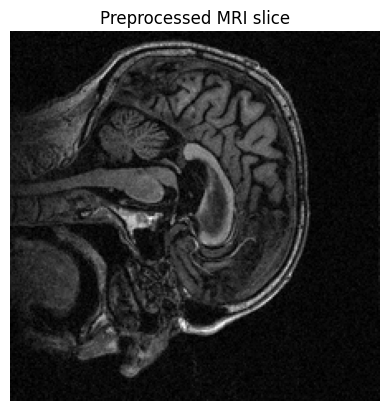

In [20]:
import matplotlib.pyplot as plt

sample_path = df[df['mri_path'].notnull()]['mri_path'].iloc[0]

print("Testing file:")
print(sample_path)

img = preprocess_mri(sample_path)

print("Output shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min(), "max:", img.max())

plt.imshow(img[:, :, 0], cmap='gray')
plt.axis('off')
plt.title("Preprocessed MRI slice")
plt.show()

In [21]:
from tqdm import tqdm
import numpy as np
import os
import pandas as pd
PROCESSED_MRI_DIR = PROJECT_ROOT + 'data/processed/mri_slices/'
os.makedirs(PROCESSED_MRI_DIR, exist_ok=True)

processed_paths = []
errors = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    mri_id = row['MRI ID']
    mri_path = row['mri_path']

    output_path = os.path.join(PROCESSED_MRI_DIR, f"{mri_id}.npy")

    if pd.isna(mri_path) or mri_path is None:
        processed_paths.append(None)
        errors.append((mri_id, "MRI path missing"))
        continue

    if os.path.exists(output_path):
        processed_paths.append(output_path)
        continue

    try:
        arr = preprocess_mri(mri_path)
        np.save(output_path, arr)
        processed_paths.append(output_path)

    except Exception as e:
        processed_paths.append(None)
        errors.append((mri_id, str(e)))

df['processed_mri_path'] = processed_paths

print("Processed:", df['processed_mri_path'].notnull().sum(), "/", len(df))
print("Errors:", len(errors))

for e in errors[:10]:
    print(e)

100%|██████████| 373/373 [39:26<00:00,  6.34s/it]

Processed: 373 / 373
Errors: 0


In [22]:
metadata_path = PROJECT_ROOT + 'data/processed/oasis_with_mri_paths.csv'

df.to_csv(metadata_path, index=False)

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/oasis_with_mri_paths.csv


In [23]:
import pickle
from sklearn.model_selection import train_test_split

df['Subject ID'] = df['Subject ID'].str.strip()

unique_subj = df.groupby('Subject ID')['Label'].agg(lambda x: x.mode()[0]).reset_index()
unique_subj.columns = ['subject_id', 'label']

subj_train, subj_temp = train_test_split(
    unique_subj,
    test_size=0.30,
    stratify=unique_subj['label'],
    random_state=42
)

subj_val, subj_test = train_test_split(
    subj_temp,
    test_size=0.50,
    stratify=subj_temp['label'],
    random_state=42
)

df['split'] = 'test'
df.loc[df['Subject ID'].isin(subj_train['subject_id']), 'split'] = 'train'
df.loc[df['Subject ID'].isin(subj_val['subject_id']), 'split'] = 'val'

split_path = PROJECT_ROOT + 'data/splits/splits.pkl'

with open(split_path, 'wb') as f:
    pickle.dump(
        {
            'train': subj_train['subject_id'].tolist(),
            'val': subj_val['subject_id'].tolist(),
            'test': subj_test['subject_id'].tolist()
        },
        f
    )

print(df.groupby(['split', 'Label']).size().unstack())
print("Saved:", split_path)

Label   CN  MA  MCI
split              
test    29  15   16
train  132  41   86
val     29   6   19
Saved: /content/drive/MyDrive/alzheimer-ai/data/splits/splits.pkl


In [24]:
def map_label(row):
    group = str(row['Group']).strip()

    if group == 'Nondemented':
        return 'CN'
    elif group == 'Converted':
        return 'MCI'
    elif group == 'Demented':
        return 'MA'
    else:
        raise ValueError(f"Unknown Group value: {group}")

df['Label'] = df.apply(map_label, axis=1)

label_map = {
    'CN': 0,
    'MCI': 1,
    'MA': 2
}

df['y'] = df['Label'].map(label_map)

print(df['Group'].value_counts())
print(df['Label'].value_counts())

Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64
Label
CN     190
MA     146
MCI     37
Name: count, dtype: int64


In [25]:
df.to_csv(PROJECT_ROOT + 'data/processed/oasis_labeled.csv', index=False)
df.to_csv(PROJECT_ROOT + 'data/processed/oasis_with_mri_paths.csv', index=False)

print("Corrected labels saved.")

Corrected labels saved.


In [26]:
import pickle
from sklearn.model_selection import train_test_split

df['Subject ID'] = df['Subject ID'].str.strip()

unique_subj = df.groupby('Subject ID')['Label'].agg(lambda x: x.mode()[0]).reset_index()
unique_subj.columns = ['subject_id', 'label']

subj_train, subj_temp = train_test_split(
    unique_subj,
    test_size=0.30,
    stratify=unique_subj['label'],
    random_state=42
)

subj_val, subj_test = train_test_split(
    subj_temp,
    test_size=0.50,
    stratify=subj_temp['label'],
    random_state=42
)

df['split'] = 'test'
df.loc[df['Subject ID'].isin(subj_train['subject_id']), 'split'] = 'train'
df.loc[df['Subject ID'].isin(subj_val['subject_id']), 'split'] = 'val'

split_path = PROJECT_ROOT + 'data/splits/splits.pkl'

with open(split_path, 'wb') as f:
    pickle.dump(
        {
            'train': subj_train['subject_id'].tolist(),
            'val': subj_val['subject_id'].tolist(),
            'test': subj_test['subject_id'].tolist()
        },
        f
    )

print(df.groupby(['split', 'Label']).size().unstack())
print("Saved:", split_path)

Label   CN   MA  MCI
split               
test    31   23    5
train  132  103   27
val     27   20    5
Saved: /content/drive/MyDrive/alzheimer-ai/data/splits/splits.pkl


In [27]:
train_subjects = set(subj_train['subject_id'])
val_subjects = set(subj_val['subject_id'])
test_subjects = set(subj_test['subject_id'])

print("Train ∩ Val:", len(train_subjects & val_subjects))
print("Train ∩ Test:", len(train_subjects & test_subjects))
print("Val ∩ Test:", len(val_subjects & test_subjects))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [28]:
df.to_csv(PROJECT_ROOT + 'data/processed/oasis_with_mri_paths.csv', index=False)
df.to_csv(PROJECT_ROOT + 'data/processed/oasis_day2_metadata.csv', index=False)

print("Corrected Day 2 metadata saved.")


Corrected Day 2 metadata saved.


In [29]:
import numpy as np

def get_tabular_features(df_split):
    """
    4-feature vector:
    [MMSE_norm, nWBV, Age_zscore, EDUC_zscore]

    Excluded:
    - eTIV: redundant / multicollinearity concern
    - ASF: related to eTIV
    """
    mmse = df_split['MMSE'].values / 30.0
    nwbv = df_split['nWBV'].values

    age_z = (df_split['Age'].values - df['Age'].mean()) / (df['Age'].std() + 1e-8)
    educ_z = (df_split['EDUC'].values - df['EDUC'].mean()) / (df['EDUC'].std() + 1e-8)

    return np.column_stack([mmse, nwbv, age_z, educ_z]).astype(np.float32)


tab_train = get_tabular_features(df[df['split'] == 'train'])
tab_val = get_tabular_features(df[df['split'] == 'val'])
tab_test = get_tabular_features(df[df['split'] == 'test'])

y_train = df[df['split'] == 'train']['y'].values
y_val = df[df['split'] == 'val']['y'].values
y_test = df[df['split'] == 'test']['y'].values

print("tab_train:", tab_train.shape)
print("tab_val:", tab_val.shape)
print("tab_test:", tab_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

tab_train: (262, 4)
tab_val: (52, 4)
tab_test: (59, 4)
y_train: (262,)
y_val: (52,)
y_test: (59,)


In [30]:
TABULAR_DIR = PROJECT_ROOT + 'data/processed/tabular/'
os.makedirs(TABULAR_DIR, exist_ok=True)

np.save(TABULAR_DIR + 'tab_train.npy', tab_train)
np.save(TABULAR_DIR + 'tab_val.npy', tab_val)
np.save(TABULAR_DIR + 'tab_test.npy', tab_test)

np.save(TABULAR_DIR + 'y_train.npy', y_train)
np.save(TABULAR_DIR + 'y_val.npy', y_val)
np.save(TABULAR_DIR + 'y_test.npy', y_test)

print("Tabular features and labels saved to:", TABULAR_DIR)

Tabular features and labels saved to: /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/


In [31]:
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

print("\nTraining class counts:")
print(dict(zip(*np.unique(y_train, return_counts=True))))

Class weights: {0: np.float64(0.6616161616161617), 1: np.float64(3.234567901234568), 2: np.float64(0.8478964401294499)}

Training class counts:
{np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}


In [32]:
class_weight_dict = {
    int(k): float(v)
    for k, v in class_weight_dict.items()
}

print(class_weight_dict)

{0: 0.6616161616161617, 1: 3.234567901234568, 2: 0.8478964401294499}


In [33]:
import pickle

with open(PROJECT_ROOT + 'data/processed/class_weight_dict.pkl', 'wb') as f:
    pickle.dump(class_weight_dict, f)

print("Saved class weights.")

Saved class weights.


In [34]:
def apply_smote(X_tab, y, random_state=42):
    """
    SMOTE fallback.
    Activate only later if MCI recall is weak after Day 3.
    """
    minority_count = np.sum(y == 1)

    if minority_count <= 1:
        raise ValueError("Not enough MCI samples for SMOTE.")

    smote = SMOTE(
        sampling_strategy='minority',
        k_neighbors=min(5, minority_count - 1),
        random_state=random_state
    )

    X_res, y_res = smote.fit_resample(X_tab, y)

    print("Before SMOTE:", dict(zip(*np.unique(y, return_counts=True))))
    print("After SMOTE:", dict(zip(*np.unique(y_res, return_counts=True))))

    return X_res, y_res

print("SMOTE function ready. Do not apply yet.")

SMOTE function ready. Do not apply yet.


In [35]:
import pickle

with open(PROJECT_ROOT + 'data/processed/class_weight_dict.pkl', 'wb') as f:
    pickle.dump(class_weight_dict, f)

print("Saved class weights.")

Saved class weights.


In [36]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add src/preprocessing.py
!git add tests/test_preprocessing.py
!git add notebooks/02_preprocessing.ipynb
!git add data/splits/splits.pkl
!git add -f data/processed/class_weight_dict.pkl

!git commit -m "feat: complete preprocessing pipeline and datasets"

!git status

/content/drive/MyDrive/alzheimer-ai
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/01_eda.ipynb
	modified:   src/preprocessing.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/splits/splits.pkl
	notebooks/02_preprocessing.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
[main fd489a0] feat: complete preprocessing pipeline and datasets
 4 files changed, 24 insertions(+), 10 deletions(-)
 create mode 100644 data/processed/class_weight_dict.pkl
 create mode 100644 data/splits/splits.pkl
 create mode 100644 notebooks/02_preprocessing.ipynb
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/01_eda.ipynb
	modified:   notebook

In [4]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

METADATA_PATH = PROJECT_ROOT + 'data/processed/oasis_day2_metadata.csv'
MRI_SLICE_DIR = PROJECT_ROOT + 'data/processed/mri_slices/'
IMAGE_ARRAY_DIR = PROJECT_ROOT + 'data/processed/image_arrays/'
TABULAR_DIR = PROJECT_ROOT + 'data/processed/tabular/'

os.makedirs(IMAGE_ARRAY_DIR, exist_ok=True)
os.makedirs(TABULAR_DIR, exist_ok=True)

df = pd.read_csv(METADATA_PATH)

print("Loaded metadata:", df.shape)
print(df.groupby(['split', 'Label']).size().unstack())
print("Columns:", df.columns.tolist())

Loaded metadata: (373, 20)
Label   CN   MA  MCI
split               
test    31   23    5
train  132  103   27
val     27   20    5
Columns: ['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Label', 'y', 'mri_path', 'processed_mri_path', 'split']


In [5]:
def get_processed_path(row):
    """
    Use processed_mri_path if available.
    Otherwise rebuild path from MRI ID.
    """
    if 'processed_mri_path' in row and pd.notna(row['processed_mri_path']):
        return row['processed_mri_path']

    return os.path.join(MRI_SLICE_DIR, f"{row['MRI ID']}.npy")


def build_image_array(df_split):
    images = []
    labels = []
    missing = []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        path = get_processed_path(row)

        if not os.path.exists(path):
            missing.append((row['MRI ID'], path))
            continue

        img = np.load(path).astype(np.float32)

        if img.shape != (224, 224, 3):
            raise ValueError(f"Bad image shape for {row['MRI ID']}: {img.shape}")

        images.append(img)
        labels.append(int(row['y']))

    if missing:
        print("Missing processed MRI files:")
        for item in missing[:10]:
            print(item)
        raise FileNotFoundError(f"{len(missing)} processed MRI files are missing.")

    return np.stack(images).astype(np.float32), np.array(labels, dtype=np.int64)


df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_val = df[df['split'] == 'val'].reset_index(drop=True)
df_test = df[df['split'] == 'test'].reset_index(drop=True)

X_train, y_train = build_image_array(df_train)
X_val, y_val = build_image_array(df_val)
X_test, y_test = build_image_array(df_test)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("Train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val class counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("Test class counts:", dict(zip(*np.unique(y_test, return_counts=True))))

100%|██████████| 59/59 [00:25<00:00,  2.31it/s]

X_train: (262, 224, 224, 3)
X_val: (52, 224, 224, 3)
X_test: (59, 224, 224, 3)
y_train: (262,)
y_val: (52,)
y_test: (59,)
Train class counts: {np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}
Val class counts: {np.int64(0): np.int64(27), np.int64(1): np.int64(5), np.int64(2): np.int64(20)}
Test class counts: {np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}


In [6]:
np.save(IMAGE_ARRAY_DIR + 'X_train.npy', X_train)
np.save(IMAGE_ARRAY_DIR + 'X_val.npy', X_val)
np.save(IMAGE_ARRAY_DIR + 'X_test.npy', X_test)

np.save(TABULAR_DIR + 'y_train.npy', y_train)
np.save(TABULAR_DIR + 'y_val.npy', y_val)
np.save(TABULAR_DIR + 'y_test.npy', y_test)

print("Saved image arrays to:", IMAGE_ARRAY_DIR)
print("Saved labels to:", TABULAR_DIR)

Saved image arrays to: /content/drive/MyDrive/alzheimer-ai/data/processed/image_arrays/
Saved labels to: /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/


In [7]:
def get_tabular_features(df_split):
    mmse = df_split['MMSE'].values / 30.0
    nwbv = df_split['nWBV'].values

    age_z = (df_split['Age'].values - df['Age'].mean()) / (df['Age'].std() + 1e-8)
    educ_z = (df_split['EDUC'].values - df['EDUC'].mean()) / (df['EDUC'].std() + 1e-8)

    return np.column_stack([mmse, nwbv, age_z, educ_z]).astype(np.float32)


tab_train = get_tabular_features(df_train)
tab_val = get_tabular_features(df_val)
tab_test = get_tabular_features(df_test)

np.save(TABULAR_DIR + 'tab_train.npy', tab_train)
np.save(TABULAR_DIR + 'tab_val.npy', tab_val)
np.save(TABULAR_DIR + 'tab_test.npy', tab_test)

print("tab_train:", tab_train.shape)
print("tab_val:", tab_val.shape)
print("tab_test:", tab_test.shape)

tab_train: (262, 4)
tab_val: (52, 4)
tab_test: (59, 4)


In [8]:
required_files = [
    IMAGE_ARRAY_DIR + 'X_train.npy',
    IMAGE_ARRAY_DIR + 'X_val.npy',
    IMAGE_ARRAY_DIR + 'X_test.npy',
    TABULAR_DIR + 'tab_train.npy',
    TABULAR_DIR + 'tab_val.npy',
    TABULAR_DIR + 'tab_test.npy',
    TABULAR_DIR + 'y_train.npy',
    TABULAR_DIR + 'y_val.npy',
    TABULAR_DIR + 'y_test.npy',
    PROJECT_ROOT + 'data/processed/class_weight_dict.pkl'
]

for f in required_files:
    print(os.path.exists(f), f)

True /content/drive/MyDrive/alzheimer-ai/data/processed/image_arrays/X_train.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/image_arrays/X_val.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/image_arrays/X_test.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/tab_train.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/tab_val.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/tab_test.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/y_train.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/y_val.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/tabular/y_test.npy
True /content/drive/MyDrive/alzheimer-ai/data/processed/class_weight_dict.pkl


In [9]:
X_train_test = np.load(IMAGE_ARRAY_DIR + 'X_train.npy')
X_val_test = np.load(IMAGE_ARRAY_DIR + 'X_val.npy')
X_test_test = np.load(IMAGE_ARRAY_DIR + 'X_test.npy')

y_train_test = np.load(TABULAR_DIR + 'y_train.npy')
y_val_test = np.load(TABULAR_DIR + 'y_val.npy')
y_test_test = np.load(TABULAR_DIR + 'y_test.npy')

print("X_train:", X_train_test.shape, X_train_test.dtype, X_train_test.min(), X_train_test.max())
print("X_val:", X_val_test.shape, X_val_test.dtype, X_val_test.min(), X_val_test.max())
print("X_test:", X_test_test.shape, X_test_test.dtype, X_test_test.min(), X_test_test.max())

print("y_train:", y_train_test.shape)
print("y_val:", y_val_test.shape)
print("y_test:", y_test_test.shape)

X_train: (262, 224, 224, 3) float32 0.0 1.0
X_val: (52, 224, 224, 3) float32 0.0 1.0
X_test: (59, 224, 224, 3) float32 0.0 1.0
y_train: (262,)
y_val: (52,)
y_test: (59,)


In [10]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git add notebooks/02_preprocessing.ipynb
!git commit -m "fix: generate image arrays for baseline training"

!git status

/content/drive/MyDrive/alzheimer-ai
[main b9d0f10] fix: generate image arrays for baseline training
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite notebooks/02_preprocessing.ipynb (96%)
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/02_preprocessing.ipynb
	modified:   notebooks/02b_feature_engineering.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/03_baseline_cnn.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
